In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6,6)

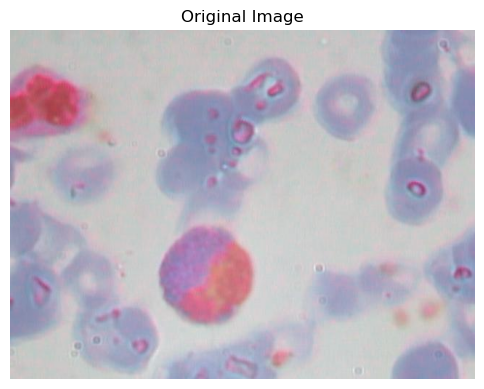

In [10]:
# Read image
img = cv2.imread(r"C:\Users\paula\Downloads\dataset-master\dataset-master\JPEGImages\BloodImage_00044.jpg")  # Put any image in your folder

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

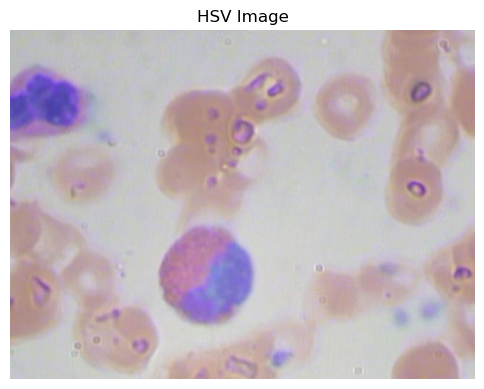

Image shape: (480, 640, 3)


In [14]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Matplotlib بيقرأ RGB، فـ نحول من HSV → RGB علشان العرض
hsv_display = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.imshow(hsv_display)
plt.title("HSV Image")
plt.axis("off")
plt.show()

print("Image shape:", hsv.shape)

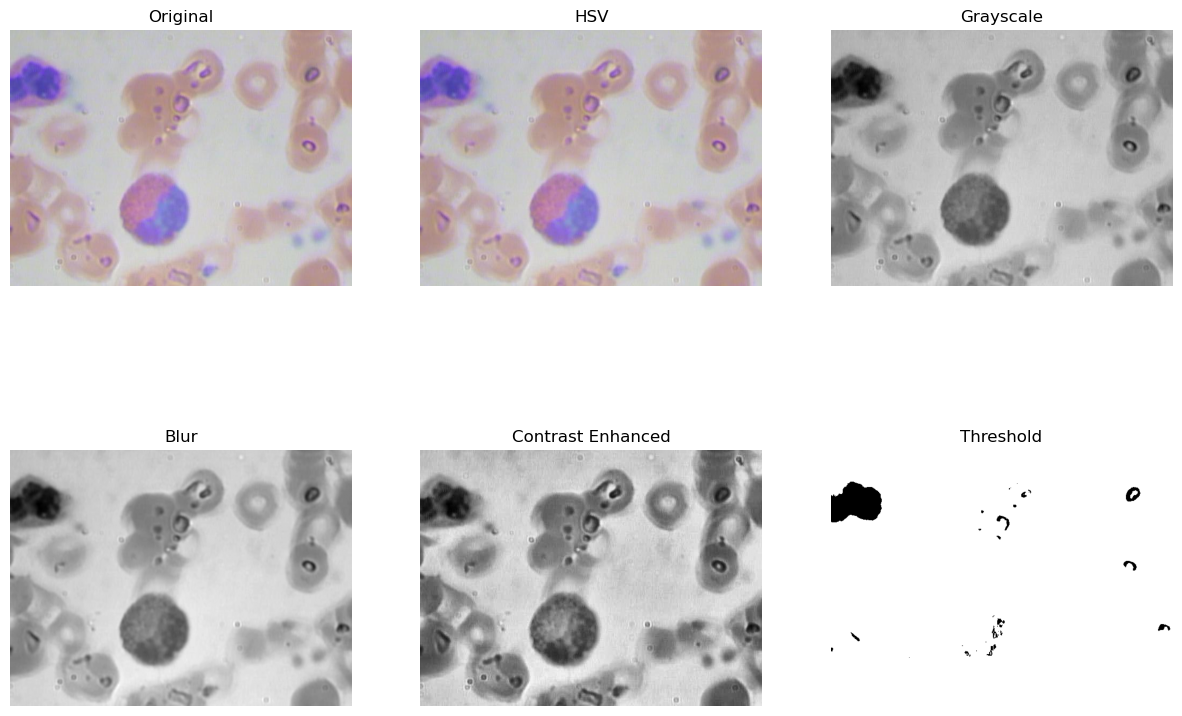

Image shape: (480, 640)


In [17]:
import cv2
import matplotlib.pyplot as plt

# Original image (BGR)
original = img

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv_display = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)  # علشان العرض في matplotlib

# 1) Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# 2) Contrast Enhancement (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(gray)

# 3) Thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Display images
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(hsv_display)
plt.title("HSV")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(blur, cmap='gray')
plt.title("Blur")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(contrast, cmap='gray')
plt.title("Contrast Enhanced")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold")
plt.axis("off")

plt.show()

print("Image shape:", gray.shape)


### Morphological Operations

In [18]:
import numpy as np

# Morphological kernel
kernel = np.ones((3,3), np.uint8)

# 1) Opening -> remove noise
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# 2) Closing -> fill holes
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

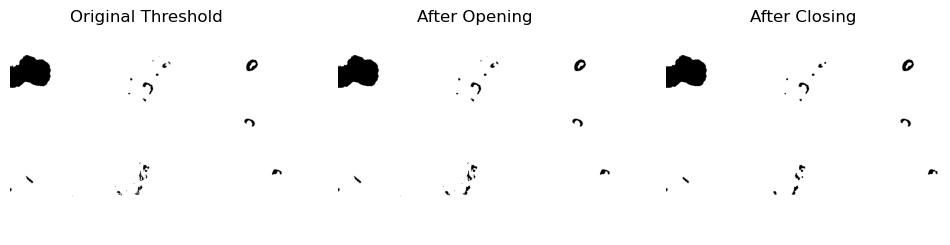

In [19]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(thresh, cmap='gray')
plt.title("Original Threshold")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(opening, cmap='gray')
plt.title("After Opening")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(closing, cmap='gray')
plt.title("After Closing")
plt.axis("off")

plt.show()

In [ ]:
import cv2
import os
import numpy as np

# ----------------------------
# Folders
# ----------------------------
folder_path = r"C:\Users\paula\OneDrive\Desktop\JPEGImages"
output_folder = "preprocessed_output"

os.makedirs(output_folder, exist_ok=True)

# Get images
images = [f for f in os.listdir(folder_path)
        if f.endswith(('.png', '.jpg', '.jpeg'))]

# ----------------------------
# Loop over images
# ----------------------------
for img_name in images:

    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # 1. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Blur
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. Contrast Enhancement (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast = clahe.apply(blur)

    # 4. Thresholding
    _, thresh = cv2.threshold(contrast, 127, 255, cv2.THRESH_BINARY)

    # 5. Morphological Operations
    kernel = np.ones((3, 3), np.uint8)

    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # ----------------------------
    # Save result
    # ----------------------------
    save_path = os.path.join(output_folder, img_name)
    cv2.imwrite(save_path, closing)

print("Preprocessing Done ✔")

Preprocessing Done ✔
